In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!apt-get install -y datalad
!pip install datalad

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  aria2 git-annex git-remote-gcrypt libaria2-0 libc-ares2 libimagequant0
  libraqm0 netbase nocache patool python3-annexremote python3-appdirs
  python3-argcomplete python3-boto python3-certifi python3-chardet
  python3-datalad python3-deprecated python3-exif python3-exifread
  python3-fasteners python3-github python3-gitlab python3-html5lib
  python3-httpretty python3-humanize python3-idna python3-iso8601
  python3-jsmin python3-keyrings.alt python3-mock python3-monotonic
  python3-msgpack python3-mutagen python3-nacl python3-nose python3-olefile
  python3-packaging python3-pbr python3-pil python3-pkg-resources
  python3-pycryptodome python3-pyperclip python3-requests
  python3-requests-toolbelt python3-setuptools python3-simplejson python3-tqdm
  python3-urllib3 python3-vcr python3-webencodings python3-whoosh
  python3-wrapt python3-yam

In [9]:
!datalad install https://github.com/OpenNeuroDatasets/ds000171.git
%cd ds000171
!datalad get sub-*/func/*bold.nii.gz
!pip install nilearn nibabel torch scikit-learn scipy seaborn --quiet

It is highly recommended to configure Git before using DataLad. Set both 'user.name' and 'user.email' configuration variables.
/kaggle/working/ds000171
It is highly recommended to configure Git before using DataLad. Set both 'user.name' and 'user.email' configuration variables.
Total:   0%|                                   | 0.00/7.08G [00:00<?, ? Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:   0%|            | 0.00/37.0M [00:00<?, ? Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:   1%|    | 364k/37.0M [00:00<00:11, 3.33M Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:   5%|▏  | 1.76M/37.0M [00:00<00:03, 9.30M Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:  10%|▎  | 3.76M/37.0M [00:00<00:02, 14.1M Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:  16%|▍  | 5.86M/37.0M [00:00<00:01, 16.7M Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:  21%|▋  | 7.89M/37.0M [00:00<00:01, 18.0M Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:  27%|▊  | 9.97M/37.0M [00:00<00:01, 18.9M Bytes/s]
Get sub-mdd0 .. _bold.nii.gz:  33%|▉  | 12.0M/37.0M [00:00<00:01, 19.4M B

In [23]:
import os, glob, warnings
import numpy as np
import pandas as pd
from pathlib import Path
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
 
from nilearn import image, connectome
from nilearn.input_data import NiftiLabelsMasker
from nilearn.datasets import fetch_atlas_destrieux_2009
 
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              roc_auc_score, classification_report)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.linalg import lstsq
from itertools import combinations
 
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
 
# ── Paths ──────────────────────────────────────
DS_ROOT = Path("/kaggle/working/ds000171")   # adjust if needed
ATLAS   = "cc200"                             # same atlas family as paper (200 ROI)
N_ROIS  = 200
FEAT_DIM = 16                                 # embedding dimension (paper uses 16)
BATCH    = 16
EPOCHS   = 60
LR       = 1e-3
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [24]:
from nilearn import datasets as nlds
 
def get_atlas():
    """
    Use Schaefer 200-ROI atlas (closest publicly available match to
    the paper's CC200 template with 200 brain regions).
    """
    atlas = nlds.fetch_atlas_schaefer_2018(n_rois=200, resolution_mm=2)
    return atlas.maps, atlas.labels
 
ATLAS_IMG, ATLAS_LABELS = get_atlas()
print(f"Atlas loaded: {len(ATLAS_LABELS)} ROIs")

[fetch_atlas_schaefer_2018] Dataset found in /root/nilearn_data/schaefer_2018

Atlas loaded: 201 ROIs


In [25]:
def discover_subjects(ds_root: Path):
    """Find all subjects and assign binary labels (0=control, 1=mdd/ptsd)."""
    records = []
    for subj_dir in sorted(ds_root.iterdir()):
        name = subj_dir.name
        if name.startswith("sub-control"):
            label = 0
        elif name.startswith("sub-mdd"):
            label = 1
        else:
            continue
        # Collect all bold runs for this subject
        bold_files = sorted(subj_dir.glob("func/*bold.nii.gz"))
        for bf in bold_files:
            records.append({"subject": name, "bold_path": str(bf), "label": label})
    df = pd.DataFrame(records)
    print(f"Found {len(df)} scans from {df['subject'].nunique()} subjects "
          f"({(df['label']==0).sum()} control, {(df['label']==1).sum()} mdd)")
    return df
 
subjects_df = discover_subjects(DS_ROOT)

Found 195 scans from 39 subjects (100 control, 95 mdd)


In [31]:
import os
import numpy as np
import pandas as pd
from nilearn.input_data import NiftiLabelsMasker
from nilearn import connectome


def extract_fc_matrix(bold_path: str, atlas_img,
                      t_r: float = 2.0,
                      low_pass: float = 0.1,
                      high_pass: float = 0.01,
                      expected_rois: int = 200) -> np.ndarray:
    """
    Extract Pearson correlation functional connectivity matrix.
    Returns None if ROI mismatch or failure.
    """

    masker = NiftiLabelsMasker(
        labels_img=atlas_img,
        standardize=True,
        detrend=True,
        low_pass=low_pass,
        high_pass=high_pass,
        t_r=t_r,
        memory_level=0,
        verbose=0
    )

    try:
        time_series = masker.fit_transform(bold_path)  # (T, n_rois)
    except Exception as e:
        print(f"⚠ Skipping {bold_path}: {e}")
        return None

    # 🚨 Ensure consistent ROI count
    if time_series.shape[1] != expected_rois:
        print(f"⚠ ROI mismatch ({time_series.shape[1]} != {expected_rois}) → skipping")
        return None

    # Pearson correlation
    corr_measure = connectome.ConnectivityMeasure(kind='correlation')
    fc = corr_measure.fit_transform([time_series])[0]

    # Fisher Z-transform
    np.fill_diagonal(fc, 0)
    fc_z = np.arctanh(np.clip(fc, -0.9999, 0.9999))

    # Upper triangle → feature vector
    triu_idx = np.triu_indices(fc_z.shape[0], k=1)
    fc_vec = fc_z[triu_idx]

    return fc_vec


def build_feature_matrix(subjects_df: pd.DataFrame, atlas_img,
                         cache_path: str = "/kaggle/working/fc_features.npz",
                         expected_rois: int = 200):

    # ✅ Safe cache loading
    if os.path.exists(cache_path):
        data = np.load(cache_path, allow_pickle=True)
        X, y, subjects = data["X"], data["y"], data["subjects"]

        if len(X) > 0:
            print("✅ Loading cached features...")
            print(f"Cached shape: {X.shape}")
            return X, y, subjects
        else:
            print("⚠ Cache empty → recomputing...")

    X_list, y_list, subj_list = [], [], []
    expected_len = None

    for _, row in subjects_df.iterrows():
        print(f"Processing {row['bold_path']} ...", end=" ")

        fc = extract_fc_matrix(row["bold_path"], atlas_img, expected_rois=expected_rois)

        if fc is None:
            print("✗ skipped")
            continue

        # 🚨 Enforce consistent feature length
        if expected_len is None:
            expected_len = len(fc)

        if len(fc) != expected_len:
            print(f"⚠ Feature mismatch ({len(fc)} != {expected_len}) → skipped")
            continue

        X_list.append(fc)
        y_list.append(row["label"])
        subj_list.append(row["subject"])

        print(f"✓ shape={fc.shape}")

    # 🚨 Final safety check
    if len(X_list) == 0:
        raise ValueError("❌ No valid samples found. Check dataset paths or atlas.")

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    subjects = np.array(subj_list)

    np.savez(cache_path, X=X, y=y, subjects=subjects)

    print("\n✅ Feature extraction complete")
    print(f"Feature matrix: {X.shape}")
    print(f"Labels: {y.shape}")

    return X, y, subjects


# 🚀 Run
X_raw, y, subjects = build_feature_matrix(subjects_df, ATLAS_IMG)

Processing /kaggle/working/ds000171/sub-control01/func/sub-control01_task-music_run-1_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-control01/func/sub-control01_task-music_run-2_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-control01/func/sub-control01_task-music_run-3_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-control01/func/sub-control01_task-nonmusic_run-4_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-control01/func/sub-control01_task-nonmusic_run-5_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-control02/func/sub-control02_task-music_run-1_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-control02/func/sub-control02_task-music_run-2_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-control02/func/sub-control02_task-music_run-3_bold.nii.gz ... ✓ shape=(19900,)
Processing /kaggle/working/ds000171/sub-co

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
 
# Stratified 80/20 split (paper uses 70–30, we use 80–20 as requested)
X_train, X_test, y_train, y_test, subj_train, subj_test = train_test_split(
    X_scaled, y, subjects,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train label dist: control={( y_train==0).sum()}, mdd={( y_train==1).sum()}")
print(f"Test  label dist: control={(y_test==0).sum()}, mdd={( y_test==1).sum()}")

Train: (152, 19900) | Test: (38, 19900)
Train label dist: control=80, mdd=72
Test  label dist: control=20, mdd=18


In [40]:
class TripletFMRIDataset(Dataset):
    """
    Online triplet mining dataset.
    Each sample returns (anchor, positive, negative, label).
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.class_indices = {
            c: torch.where(self.y == c)[0] for c in self.y.unique().tolist()
        }
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        anchor      = self.X[idx]
        anchor_lbl  = self.y[idx].item()
        pos_class   = anchor_lbl
        neg_class   = 1 - anchor_lbl  # binary problem
 
        pos_idx = self.class_indices[pos_class]
        neg_idx = self.class_indices[neg_class]
 
        # Random positive (different from anchor)
        pos_candidates = pos_idx[pos_idx != idx]
        if len(pos_candidates) == 0:
            pos_candidates = pos_idx
        p = pos_candidates[torch.randint(len(pos_candidates), (1,))].item()
 
        # Random negative
        n = neg_idx[torch.randint(len(neg_idx), (1,))].item()
 
        return anchor, self.X[p], self.X[n], self.y[idx]
 
 
class InferenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]
 

In [41]:
class FeatureExtractorBlock(nn.Module):
    """
    FM block: Convolution + ReLU + MaxPool (CRM layers).
    Input is treated as 1D signal over FC features.
    """
    def __init__(self, in_channels: int, out_channels: int, kernel: int = 3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel,
                              padding=kernel // 2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
 
    def forward(self, x):
        return self.pool(self.relu(self.conv(x)))
 
 
class TripletNet(nn.Module):
    """
    Triplet network matching paper architecture:
    - 2 CRM layers (Feature extraction block)
    - 3 linear layers (Dimension reduction block)
    - Optional classification head for DL accuracy baseline
    """
    def __init__(self, input_dim: int, feat_dim: int = 16, n_classes: int = 2):
        super().__init__()
        self.input_dim = input_dim
 
        # Reshape input to (B, 1, input_dim) for 1D conv
        self.crm1 = FeatureExtractorBlock(1, 6, kernel=3)
        self.crm2 = FeatureExtractorBlock(6, 16, kernel=3)
 
        # Compute flattened size after two CRM layers
        dummy = torch.zeros(1, 1, input_dim)
        with torch.no_grad():
            crm_out = self.crm2(self.crm1(dummy))
        flat_size = crm_out.view(1, -1).shape[1]
 
        # DR block: 3 linear layers
        self.dr = nn.Sequential(
            nn.Linear(flat_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, feat_dim),
        )
 
        # Classification head (for DL accuracy baseline)
        self.classifier = nn.Linear(feat_dim, n_classes)
 
    def embed(self, x):
        """Returns feat_dim embedding."""
        if x.dim() == 2:
            x = x.unsqueeze(1)                  # (B, 1, D)
        x = self.crm2(self.crm1(x))
        x = x.view(x.size(0), -1)
        return self.dr(x)
 
    def forward(self, anchor, positive, negative):
        fa = self.embed(anchor)
        fp = self.embed(positive)
        fn = self.embed(negative)
        return fa, fp, fn
 
    def classify(self, x):
        emb = self.embed(x)
        return self.classifier(emb), emb

In [42]:
class IntraclassVarianceTripletLoss(nn.Module):
    """
    Novel triplet loss from the paper (Equations 1–3):
 
    J_ic = d+ + log(exp(-d+) + exp(-d-))
 
    where:
      d+ = ||α1 · ((μ+ - f(x+))² - σ+²)||
      d- = ||α2 · ((μ+ - f(x-))² - σ+²)||
 
    α_k = 0 if |f_k(x) - μ+_k| < σ+_k, else 1
        (focuses loss on features deviating beyond 1 std from class mean)
 
    Key differences from standard triplet loss:
    1. Anchor = class mean (not a single sample)
    2. Log-based distance instead of Euclidean margin
    3. Intra-class variance correction (α masking)
    """
    def __init__(self, margin: float = 0.5):
        super().__init__()
        self.margin = margin
 
    def forward(self, anchor_emb, pos_emb, neg_emb):
        """
        anchor_emb: (B, D) – the anchor (we use it as is, class mean applied below)
        pos_emb:    (B, D) – positive samples
        neg_emb:    (B, D) – negative samples
        """
        # Class mean and variance of positive embeddings (batch statistics)
        mu_pos   = pos_emb.mean(dim=0, keepdim=True)   # (1, D)
        var_pos  = pos_emb.var(dim=0, keepdim=True)     # (1, D)
        sigma_pos = var_pos.sqrt() + 1e-8               # (1, D)
 
        # α masks: 1 where feature deviates beyond 1σ from class mean
        alpha1 = (( pos_emb - mu_pos).abs() > sigma_pos).float()   # (B, D)
        alpha2 = (( neg_emb - mu_pos).abs() > sigma_pos).float()   # (B, D)
 
        # Squared deviations corrected by variance
        d_pos_sq = alpha1 * ((mu_pos - pos_emb).pow(2) - var_pos)  # (B, D)
        d_neg_sq = alpha2 * ((mu_pos - neg_emb).pow(2) - var_pos)  # (B, D)
 
        # L2 norm over feature dimension
        d_plus  = d_pos_sq.norm(dim=1)   # (B,)
        d_minus = d_neg_sq.norm(dim=1)   # (B,)
 
        # Log-based triplet criterion (Eq. 1)
        loss = d_plus + torch.log(
            torch.exp(-d_plus) + torch.exp(-d_minus) + 1e-8
        )
        return loss.mean()

In [43]:
def train_model(X_train, y_train, input_dim, epochs=EPOCHS, lr=LR, device=DEVICE):
    dataset    = TripletFMRIDataset(X_train, y_train)
    loader     = DataLoader(dataset, batch_size=BATCH, shuffle=True, drop_last=False)
 
    model      = TripletNet(input_dim=input_dim, feat_dim=FEAT_DIM).to(device)
    triplet_loss = IntraclassVarianceTripletLoss()
    ce_loss    = nn.CrossEntropyLoss()
    optimizer  = optim.Adamax(model.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
 
    history = {"triplet": [], "ce": [], "total": []}
 
    model.train()
    for epoch in range(epochs):
        ep_triplet, ep_ce, ep_total = [], [], []
        for anc, pos, neg, lbl in loader:
            anc, pos, neg, lbl = anc.to(device), pos.to(device), neg.to(device), lbl.to(device)
 
            fa, fp, fn = model(anc, pos, neg)
            t_loss = triplet_loss(fa, fp, fn)
 
            # Classification head loss (standard CE, Eq supplement)
            logits, _ = model.classify(anc)
            c_loss = ce_loss(logits, lbl)
 
            loss = t_loss + 0.5 * c_loss   # joint training
 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
 
            ep_triplet.append(t_loss.item())
            ep_ce.append(c_loss.item())
            ep_total.append(loss.item())
 
        scheduler.step()
        history["triplet"].append(np.mean(ep_triplet))
        history["ce"].append(np.mean(ep_ce))
        history["total"].append(np.mean(ep_total))
 
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] "
                  f"Triplet: {history['triplet'][-1]:.4f} | "
                  f"CE: {history['ce'][-1]:.4f} | "
                  f"Total: {history['total'][-1]:.4f}")
 
    return model, history
 
 
print("Training model...")
model, history = train_model(X_train, y_train, input_dim=X_train.shape[1])

Training model...
Epoch [ 10/60] Triplet: 0.6917 | CE: 0.4776 | Total: 0.9305
Epoch [ 20/60] Triplet: 0.6411 | CE: 0.2654 | Total: 0.7738
Epoch [ 30/60] Triplet: 0.6581 | CE: 0.2071 | Total: 0.7616
Epoch [ 40/60] Triplet: 0.6208 | CE: 0.1607 | Total: 0.7011
Epoch [ 50/60] Triplet: 0.6128 | CE: 0.1547 | Total: 0.6901
Epoch [ 60/60] Triplet: 0.5945 | CE: 0.1351 | Total: 0.6620


In [44]:
def get_embeddings(model, X, device=DEVICE, batch_size=32):
    model.eval()
    ds  = InferenceDataset(X, np.zeros(len(X), dtype=np.int64))
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=False)
    embs, logits_all = [], []
    with torch.no_grad():
        for xb, _ in dl:
            xb = xb.to(device)
            logit, emb = model.classify(xb)
            embs.append(emb.cpu().numpy())
            logits_all.append(logit.cpu().numpy())
    return np.vstack(embs), np.vstack(logits_all)
 
 
train_emb, train_logits = get_embeddings(model, X_train)
test_emb,  test_logits  = get_embeddings(model, X_test)
 
# DL classification accuracy (baseline)
dl_preds_train = np.argmax(train_logits, axis=1)
dl_preds_test  = np.argmax(test_logits,  axis=1)
print(f"\nDL Classification Accuracy (train): {accuracy_score(y_train, dl_preds_train)*100:.2f}%")
print(f"DL Classification Accuracy (test):  {accuracy_score(y_test,  dl_preds_test )*100:.2f}%")


DL Classification Accuracy (train): 100.00%
DL Classification Accuracy (test):  100.00%


In [46]:
def fit_hypersphere(points: np.ndarray, max_iter: int = 100,
                    welsh_c: float = 0.112, tol: float = 1e-6):
   
    p, d = points.shape
 
    # Build system B = A · H  (Eq. 4)
    # A rows: [2*a1, 2*a2, ..., 2*ad, 1]
    # B rows: sum of a_i^2
    # H:      [h1, ..., hd, r^2 - sum(h_i^2)]
    A = np.hstack([2 * points, np.ones((p, 1))])        # (p, d+1)
    B = np.sum(points ** 2, axis=1)                      # (p,)
 
    # Initialise with uniform weights
    weights = np.ones(p)
    H_prev  = np.zeros(d + 1)
 
    for i in range(max_iter):
        W  = np.diag(weights)
        AtW = A.T @ W
        try:
            H = np.linalg.solve(AtW @ A, AtW @ B)
        except np.linalg.LinAlgError:
            H, _, _, _ = lstsq(AtW @ A, AtW @ B)
 
        # Residuals
        residuals = B - A @ H                            # (p,)
 
        # Welsh weights (Eq. 7)
        weights = np.exp(-welsh_c * residuals ** 2)
 
        if np.linalg.norm(H - H_prev) < tol:
            break
        H_prev = H.copy()
 
    center = H[:d]
    r_sq   = H[d] + np.dot(center, center)
    radius = np.sqrt(np.abs(r_sq))
    return center, radius
 
 
class HyperspherePureClassifier:
    
    def __init__(self, threshold: float = 0.05):
        
        self.threshold = threshold
        self.spheres   = {}   # class_label → (center, radius)
 
    def fit(self, X: np.ndarray, y: np.ndarray):
        for cls in np.unique(y):
            pts = X[y == cls]
            center, radius = fit_hypersphere(pts)
            # Expand radius slightly based on threshold parameter
            radius *= (1.0 + self.threshold)
            self.spheres[cls] = (center, radius)
            print(f"  Class {cls}: center_norm={np.linalg.norm(center):.4f}, "
                  f"radius={radius:.4f}, n_pts={len(pts)}")
        return self
 
    def predict(self, X: np.ndarray):
        
        membership = {}
        for cls, (center, radius) in self.spheres.items():
            dists = np.linalg.norm(X - center, axis=1)
            membership[cls] = dists <= radius
 
        preds = np.full(len(X), -1, dtype=int)  # -1 = mixed
        for cls, inside in membership.items():
            # Only assign if inside this sphere AND not already assigned
            new_pure = inside & (preds == -1)
            preds[new_pure] = cls
            # Conflict: inside both spheres → mixed
            conflict = inside & (preds != -1) & (preds != cls)
            preds[conflict] = -1
 
        in_mask = preds != -1
        return preds, in_mask
 
    def pure_class_probability(self, X: np.ndarray,
                               n_bootstrap: int = 50,
                               noise_scale: float = 1e-3):
        
        pure_counts = np.zeros(len(X))
        for _ in range(n_bootstrap):
            noise = np.random.randn(*X.shape) * noise_scale
            preds, mask = self.predict(X + noise)
            pure_counts += mask.astype(float)
        return pure_counts / n_bootstrap

In [47]:
print("\n── Fitting Hyperspheres ──")
hs_clf = HyperspherePureClassifier(threshold=0.05)
hs_clf.fit(train_emb, y_train)
 
# Predictions on test set
test_preds, test_pure_mask = hs_clf.predict(test_emb)
pure_probs = hs_clf.pure_class_probability(test_emb, n_bootstrap=60)
 
# ── Summary Statistics ──────────────────────
n_total    = len(y_test)
n_pure     = test_pure_mask.sum()
n_mixed    = n_total - n_pure
pct_pure   = n_pure  / n_total * 100
pct_mixed  = n_mixed / n_total * 100
 
print(f"\n{'='*55}")
print(f"  PURE/MIXED CLASS BREAKDOWN (Test Set)")
print(f"{'='*55}")
print(f"  Total test samples : {n_total}")
print(f"  Pure (confident)   : {n_pure}  ({pct_pure:.1f}%)")
print(f"  Mixed (uncertain)  : {n_mixed} ({pct_mixed:.1f}%)")
print(f"{'='*55}")
 
if n_pure > 0:
    # Evaluate ONLY on pure samples
    y_pure_true = y_test[test_pure_mask]
    y_pure_pred = test_preds[test_pure_mask]
 
    acc_pure  = accuracy_score(y_pure_true, y_pure_pred) * 100
    conf_mat  = confusion_matrix(y_pure_true, y_pure_pred)
 
    tn, fp, fn, tp = conf_mat.ravel() if conf_mat.size == 4 else (0,0,0,n_pure)
    pure_fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    pure_fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
 
    # Class-wise pure percentages
    ctrl_mask   = (y_test == 0) & test_pure_mask
    mdd_mask    = (y_test == 1) & test_pure_mask
    pct_ctrl    = ctrl_mask.sum() / (y_test == 0).sum() * 100
    pct_mdd     = mdd_mask.sum()  / (y_test == 1).sum() * 100
 
    print(f"\n  Pure Class Accuracy  : {acc_pure:.2f}%")
    print(f"  FP rate (pure only)  : {pure_fp_rate:.4f}")
    print(f"  FN rate (pure only)  : {pure_fn_rate:.4f}")
    print(f"  Control in Pure      : {pct_ctrl:.1f}%")
    print(f"  MDD/Trauma in Pure   : {pct_mdd:.1f}%")
    print(f"\n  High-confidence (≥95% prob) pure:")
    hc_mask = pure_probs[test_pure_mask] >= 0.95
    print(f"    {hc_mask.sum()} / {n_pure} samples ({hc_mask.mean()*100:.1f}%)")
 
    print(f"\n  Classification Report (Pure Samples Only):")
    print(classification_report(y_pure_true, y_pure_pred,
                                target_names=["Control", "MDD/Trauma"]))
else:
    print("  No pure samples found – try adjusting threshold or re-running.")


── Fitting Hyperspheres ──
  Class 0: center_norm=5.5498, radius=4.4539, n_pts=80
  Class 1: center_norm=5.6966, radius=4.7934, n_pts=72

  PURE/MIXED CLASS BREAKDOWN (Test Set)
  Total test samples : 38
  Pure (confident)   : 30  (78.9%)
  Mixed (uncertain)  : 8 (21.1%)

  Pure Class Accuracy  : 100.00%
  FP rate (pure only)  : 0.0000
  FN rate (pure only)  : 0.0000
  Control in Pure      : 65.0%
  MDD/Trauma in Pure   : 94.4%

  High-confidence (≥95% prob) pure:
    30 / 30 samples (100.0%)

  Classification Report (Pure Samples Only):
              precision    recall  f1-score   support

     Control       1.00      1.00      1.00        13
  MDD/Trauma       1.00      1.00      1.00        17

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



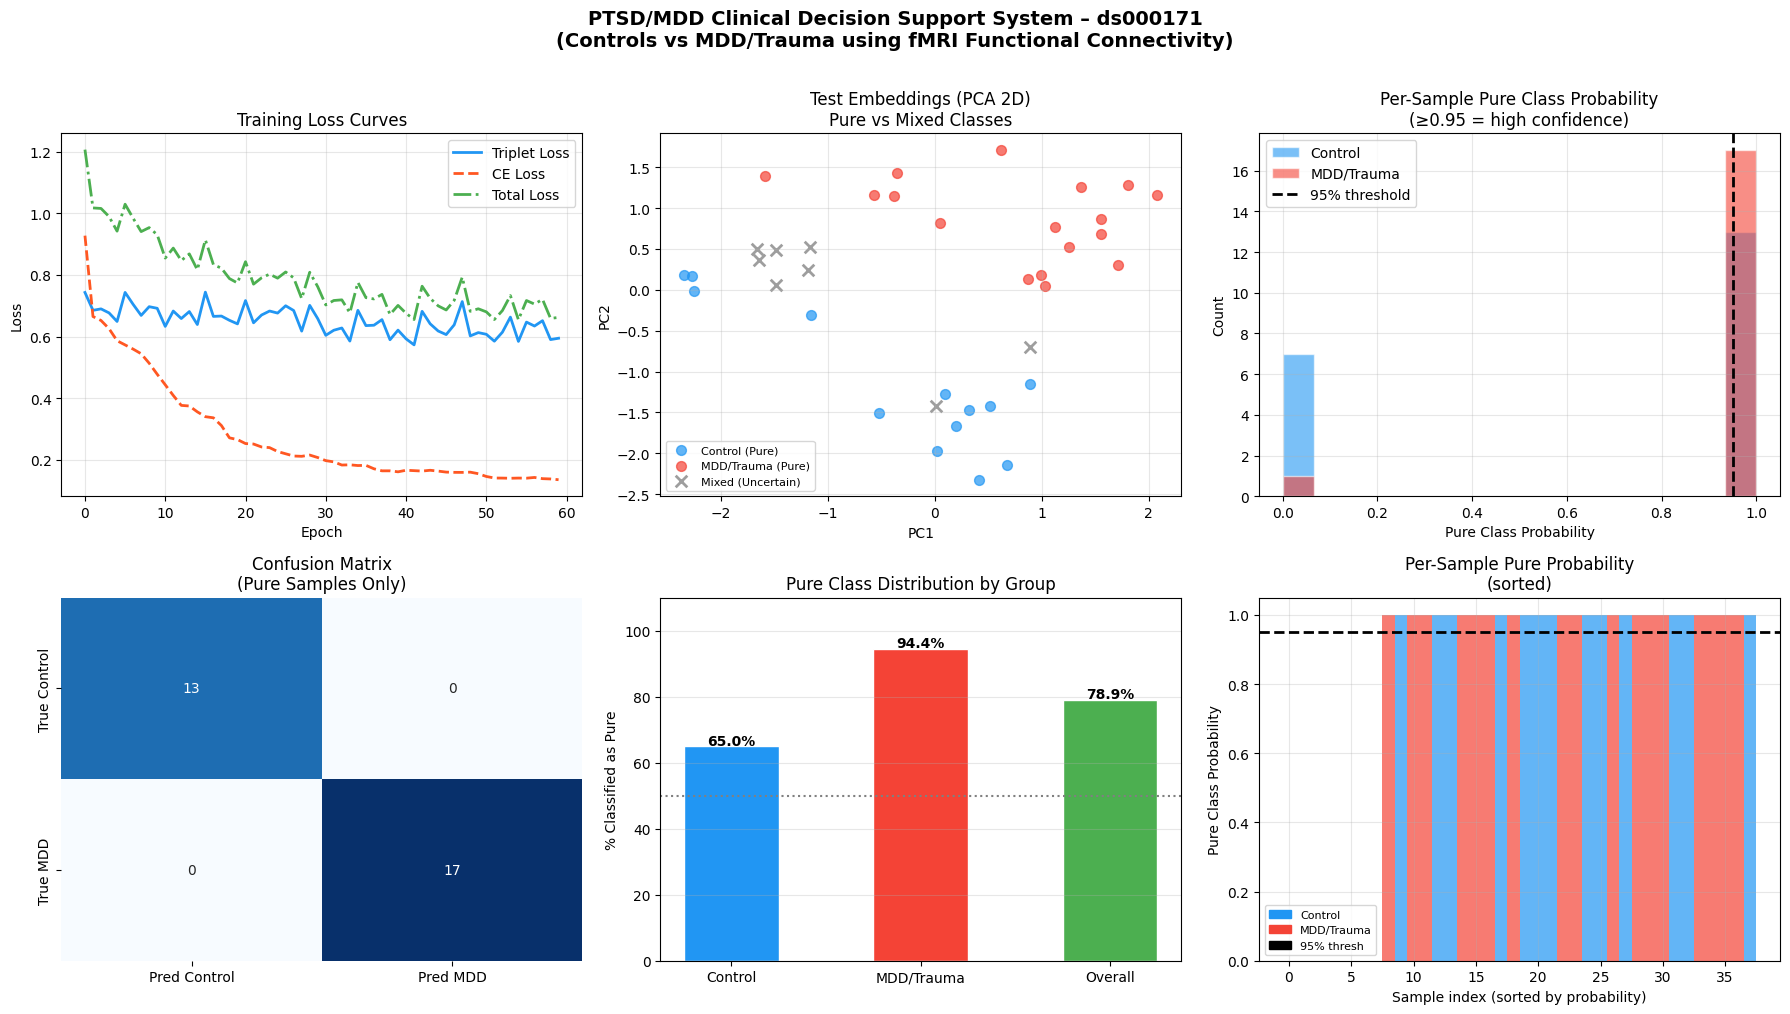

Figure saved to /kaggle/working/ptsd_cdss_results.png


In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("PTSD/MDD Clinical Decision Support System – ds000171\n"
             "(Controls vs MDD/Trauma using fMRI Functional Connectivity)",
             fontsize=14, fontweight='bold', y=1.01)
 
# ── (a) Training Loss Curves ──────────────────
ax = axes[0, 0]
ax.plot(history["triplet"], label="Triplet Loss", color="#2196F3", lw=2)
ax.plot(history["ce"],      label="CE Loss",      color="#FF5722", lw=2, ls='--')
ax.plot(history["total"],   label="Total Loss",   color="#4CAF50", lw=2, ls='-.')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss Curves")
ax.legend(); ax.grid(alpha=0.3)
 
# ── (b) Embedding scatter (first 2 PCA dims) ─
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
test_emb_2d = pca.fit_transform(test_emb)
ax = axes[0, 1]
colors = {0: "#2196F3", 1: "#F44336"}
labels_str = {0: "Control (Pure)", 1: "MDD/Trauma (Pure)"}
for cls in [0, 1]:
    m = (y_test == cls) & test_pure_mask
    ax.scatter(test_emb_2d[m, 0], test_emb_2d[m, 1],
               c=colors[cls], label=labels_str[cls], alpha=0.7, s=50)
mixed_m = ~test_pure_mask
ax.scatter(test_emb_2d[mixed_m, 0], test_emb_2d[mixed_m, 1],
           c="#9E9E9E", marker='x', label="Mixed (Uncertain)", s=70, lw=2)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Test Embeddings (PCA 2D)\nPure vs Mixed Classes")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
# ── (c) Pure class probability histogram ──────
ax = axes[0, 2]
ctrl_probs = pure_probs[y_test == 0]
mdd_probs  = pure_probs[y_test == 1]
ax.hist(ctrl_probs, bins=15, alpha=0.6, color="#2196F3",
        label="Control", edgecolor='white')
ax.hist(mdd_probs,  bins=15, alpha=0.6, color="#F44336",
        label="MDD/Trauma", edgecolor='white')
ax.axvline(0.95, color='black', ls='--', lw=2, label="95% threshold")
ax.set_xlabel("Pure Class Probability"); ax.set_ylabel("Count")
ax.set_title("Per-Sample Pure Class Probability\n(≥0.95 = high confidence)")
ax.legend(); ax.grid(alpha=0.3)
 
# ── (d) Confusion matrix (pure samples only) ──
ax = axes[1, 0]
if n_pure > 0:
    cm = confusion_matrix(y_pure_true, y_pure_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Pred Control", "Pred MDD"],
                yticklabels=["True Control", "True MDD"],
                ax=ax, cbar=False)
    ax.set_title("Confusion Matrix\n(Pure Samples Only)")
else:
    ax.text(0.5, 0.5, "No pure samples", ha='center', va='center')
    ax.set_title("Confusion Matrix")
 
# ── (e) Pure % per class bar chart ────────────
ax = axes[1, 1]
if n_pure > 0:
    cats    = ["Control", "MDD/Trauma", "Overall"]
    pct_vals = [pct_ctrl, pct_mdd, pct_pure]
    bar_colors = ["#2196F3", "#F44336", "#4CAF50"]
    bars = ax.bar(cats, pct_vals, color=bar_colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, pct_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha='center', fontweight='bold')
    ax.set_ylim(0, 110)
    ax.set_ylabel("% Classified as Pure")
    ax.set_title("Pure Class Distribution by Group")
    ax.axhline(50, color='gray', ls=':', lw=1.5)
    ax.grid(axis='y', alpha=0.3)
 
# ── (f) Sample-wise pure probability plot ─────
ax = axes[1, 2]
sorted_idx  = np.argsort(pure_probs)
x_range     = np.arange(len(pure_probs))
ax.bar(x_range, pure_probs[sorted_idx],
       color=["#2196F3" if y_test[i] == 0 else "#F44336"
              for i in sorted_idx],
       alpha=0.7, width=1.0)
ax.axhline(0.95, color='black', ls='--', lw=2, label="95% threshold")
patch_ctrl = mpatches.Patch(color='#2196F3', label='Control')
patch_mdd  = mpatches.Patch(color='#F44336', label='MDD/Trauma')
ax.legend(handles=[patch_ctrl, patch_mdd,
                   mpatches.Patch(color='black', label='95% thresh')],
          fontsize=8)
ax.set_xlabel("Sample index (sorted by probability)")
ax.set_ylabel("Pure Class Probability")
ax.set_title("Per-Sample Pure Probability\n(sorted)")
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("/kaggle/working/ptsd_cdss_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to /kaggle/working/ptsd_cdss_results.png")